<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

import os
import platform
from tensorflow.keras.preprocessing.text import text_to_word_sequence
import plotly.graph_objects as go
import plotly.express as px
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [195]:
# Descargar la carpeta de dataset
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [196]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [197]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

C:\Users\Melin\AppData\Local\Temp\ipykernel_16896\3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [198]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [199]:
sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [200]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [201]:
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [202]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [203]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [204]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [205]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [206]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625


Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [207]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [208]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [209]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [210]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [211]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [212]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [213]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [214]:
def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [215]:
# Graficar los embedddings en 2D
vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
# fig.show(renderer="colab") # esto para plotly en colab
fig.show(renderer="browser") # esto para plotly en browser

In [216]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
# fig.show(renderer="colab") # esto para plotly en colab
fig.show(renderer="browser") # esto para plotly en browser

In [217]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

Voy a utilizar el libro "Crimen y Castigo" de Fiódor Dostoyevski como corpus. Lo importo y realizo un parseo de los documentos:

In [246]:
with open('./crime-and-punishment.txt', encoding='utf-8') as fp:
  raw_text = fp.read()

# Limpio caracteres que aparecen bastante en el corpus y que no conforman palabras
remove_list = [',', '.', ';', '!', '?', '“', '”', '_', '’']
for char in remove_list:
  raw_text = raw_text.replace(char, '')

crime_paragraphs = []
 # Los parrafos estan separados por una linea vacia
for paragraph in raw_text.split('\n\n'):
  cleaned = ' '.join(paragraph.split()).strip() # Limpio el texto sacando saltos de linea y espacios extra
  if not cleaned:
    continue
  if cleaned.startswith('PART ') or cleaned.startswith('CHAPTER '): # Saco los titulos de los capitulos y partes
    continue
  crime_paragraphs.append(cleaned.lower())

df_crime = pd.DataFrame(crime_paragraphs)
print('Cantidad de documentos:', df_crime.shape[0])
df_crime.head()

Cantidad de documentos: 3907


,0
0,on an exceptionally hot evening early in july ...
1,he had successfully avoided meeting his landla...
2,this was not because he was cowardly and abjec...
3,this evening however on coming out into the st...
4,i want to attempt a thing like that and am fri...


Preprocesamiento: transformo las oraciones en una secuencia de palabras

In [247]:
sentence_tokens = []
for _, row in df_crime[:None].iterrows():
  sentence_tokens.append(text_to_word_sequence(row[0]))

sentence_tokens[:2]

[['on',
  'an',
  'exceptionally',
  'hot',
  'evening',
  'early',
  'in',
  'july',
  'a',
  'young',
  'man',
  'came',
  'out',
  'of',
  'the',
  'garret',
  'in',
  'which',
  'he',
  'lodged',
  'in',
  's',
  'place',
  'and',
  'walked',
  'slowly',
  'as',
  'though',
  'in',
  'hesitation',
  'towards',
  'k',
  'bridge'],
 ['he',
  'had',
  'successfully',
  'avoided',
  'meeting',
  'his',
  'landlady',
  'on',
  'the',
  'staircase',
  'his',
  'garret',
  'was',
  'under',
  'the',
  'roof',
  'of',
  'a',
  'high',
  'five',
  'storied',
  'house',
  'and',
  'was',
  'more',
  'like',
  'a',
  'cupboard',
  'than',
  'a',
  'room',
  'the',
  'landlady',
  'who',
  'provided',
  'him',
  'with',
  'garret',
  'dinners',
  'and',
  'attendance',
  'lived',
  'on',
  'the',
  'floor',
  'below',
  'and',
  'every',
  'time',
  'he',
  'went',
  'out',
  'he',
  'was',
  'obliged',
  'to',
  'pass',
  'her',
  'kitchen',
  'the',
  'door',
  'of',
  'which',
  'invariably

Creo los vectores con word2vec y entreno los embeddings:

In [248]:
w2v_model = Word2Vec(min_count=5,
                           window=2,
                           vector_size=300,
                           negative=20,
                           workers=1,
                           sg=1)

w2v_model.build_vocab(sentence_tokens)

print('Cantidad de docs en el corpus:', w2v_model.corpus_count)
print('Cantidad de words distintas en el corpus:', len(w2v_model.wv.index_to_key))

w2v_model.train(sentence_tokens,
                      total_examples=w2v_model.corpus_count,
                      epochs=20,
                      compute_loss=True,
                      callbacks=[callback()])

Cantidad de docs en el corpus: 3907
Cantidad de words distintas en el corpus: 3084
Loss after epoch 0: 1751103.375
Loss after epoch 1: 1241955.375
Loss after epoch 2: 1184304.5
Loss after epoch 3: 1099080.25
Loss after epoch 4: 1091843.5
Loss after epoch 5: 1082453.0
Loss after epoch 6: 1067989.0
Loss after epoch 7: 1022142.0
Loss after epoch 8: 1015580.0
Loss after epoch 9: 1010530.0
Loss after epoch 10: 1002066.0
Loss after epoch 11: 994139.0
Loss after epoch 12: 989594.0
Loss after epoch 13: 982128.0
Loss after epoch 14: 974622.0
Loss after epoch 15: 948504.0
Loss after epoch 16: 942220.0
Loss after epoch 17: 935714.0
Loss after epoch 18: 935302.0
Loss after epoch 19: 934250.0


(2724699, 4083400)

Analizo algunos resultados, como nombres de los personajes:

In [257]:
def show_similar_words(word, model, topn=10):
  print(f"Palabras que más se relacionan con '{word}':")
  similar_words = model.wv.most_similar(positive=[word], topn=topn)
  for similar_word, similarity in similar_words:
    print(f"{similar_word}: {similarity:.4f}")

show_similar_words('raskolnikov', w2v_model)
show_similar_words('sonia', w2v_model)
show_similar_words('murder', w2v_model)
show_similar_words('crime', w2v_model)

Palabras que más se relacionan con 'raskolnikov':
gloomily: 0.5571
frowning: 0.5528
dreamily: 0.5493
cautiously: 0.5406
anxiously: 0.5376
dryly: 0.5375
sharply: 0.5351
firmly: 0.5339
contemptuously: 0.5251
zossimov: 0.5238
Palabras que más se relacionan con 'sonia':
jesus: 0.5507
hush: 0.5262
dreadfully: 0.5018
irritably: 0.4995
weakly: 0.4969
mistrustfully: 0.4913
saith: 0.4899
faintly: 0.4879
impatiently: 0.4846
martha: 0.4835
Palabras que más se relacionan con 'murder':
steal: 0.6858
devil: 0.6351
widow: 0.6223
mention: 0.6179
rob: 0.6164
killing: 0.6131
disease: 0.6092
fainted: 0.6040
thanks: 0.6033
doubts: 0.6010
Palabras que más se relacionan con 'crime':
criminal: 0.6507
disease: 0.6417
mere: 0.6291
psychologically: 0.6269
community: 0.6230
health: 0.6208
progress: 0.6175
date: 0.6167
category: 0.6152
causes: 0.6087


Podemos observar que al haber utilizado como corpus un único libro, el modelo aprende algunas relaciones semánticas pero sobre todo aprende relaciones específicas de ese libro. Por ejemplo, al analizar las palabras cercanas al protagonista Raskolnikov aparecen palabras como "gloomily", "frowning", "dreamly", "dryly", "sharply", "firmly" y "contemptuously" que se pueden relacionar con sus estados de ánimo depresivos y reflexivos, como tambien con el tono de muchas de sus conversaciones que suelen ser secas y bruscas. También aparecen "cautiously" y "anxiously" que podemos relacionar con su constante estado de alerta y preocupación de ser descubrierto.

Para el vector de Sonia, que representa para el protagonista la salvación espiritual, el amor incondicional y la redención a través del sufrimiento, el modelo encontró como palabra más cercana "jesus", lo cual también tiene sentido ya que Sonia le lee al protagonista algunos pasajes bíblicos. También relacionó palabras como "hush", "dreadfully", "irritably", "weakly", "mistrustfully" y "impatiently" que podemos asociar con su comportamiento, su sufrimiento y varios momentos tensos que pasó con otros personajes.

En el caso de "murder" y "crime" se puede observar que el modelo sí logra encontrar algunas relaciones semánticas ya que los asocia a palabras como "steal", "rob", "killing", "disease", "fainted", "criminal" y "health".

In [261]:
# Graficar los embeddings de Crime and Punishment en 2D
vecs_crime, labels_crime = reduce_dimensions(w2v_model)

MAX_WORDS = 200
fig = px.scatter(x=vecs_crime[:MAX_WORDS, 0], y=vecs_crime[:MAX_WORDS, 1], text=labels_crime[:MAX_WORDS])
# fig.show(renderer="colab") # esto para plotly en colab
fig.show(renderer="browser") # esto para plotly en local

Resultado:

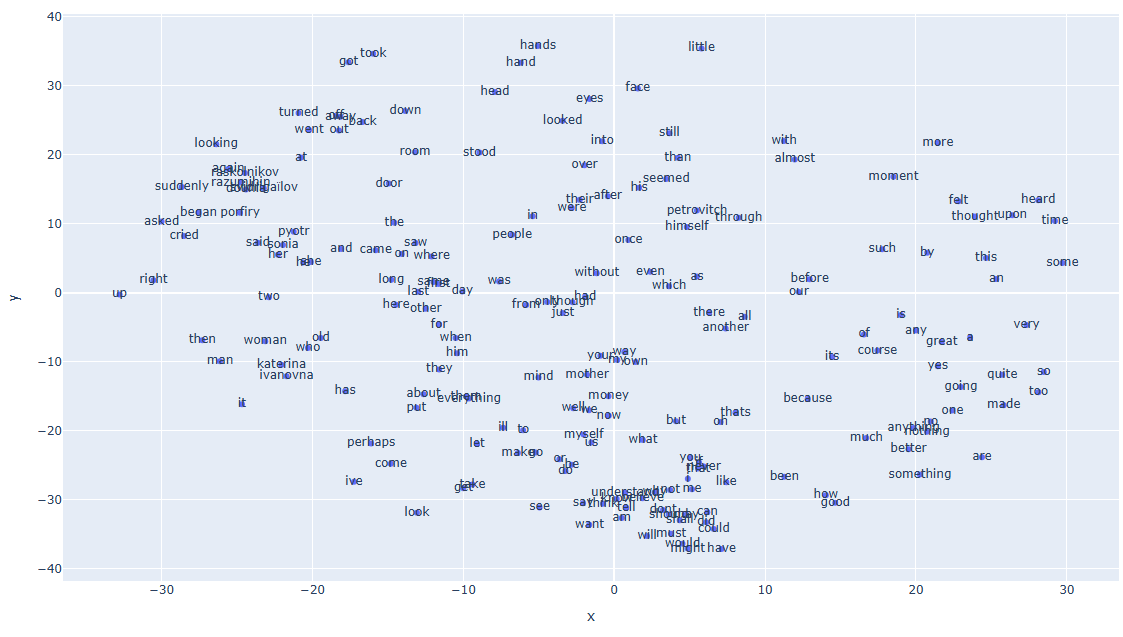

Podemos observar algunas relaciones interesantes como por ejemplo en la siguiente imagen se ve que el modelo agrupa palabras similares como "think", "know", "understand", "believe" y "want" y también se observa otro grupo cercano conformado por palabras como "should", "shall", "may", "can", "could", "would", "might", "must":

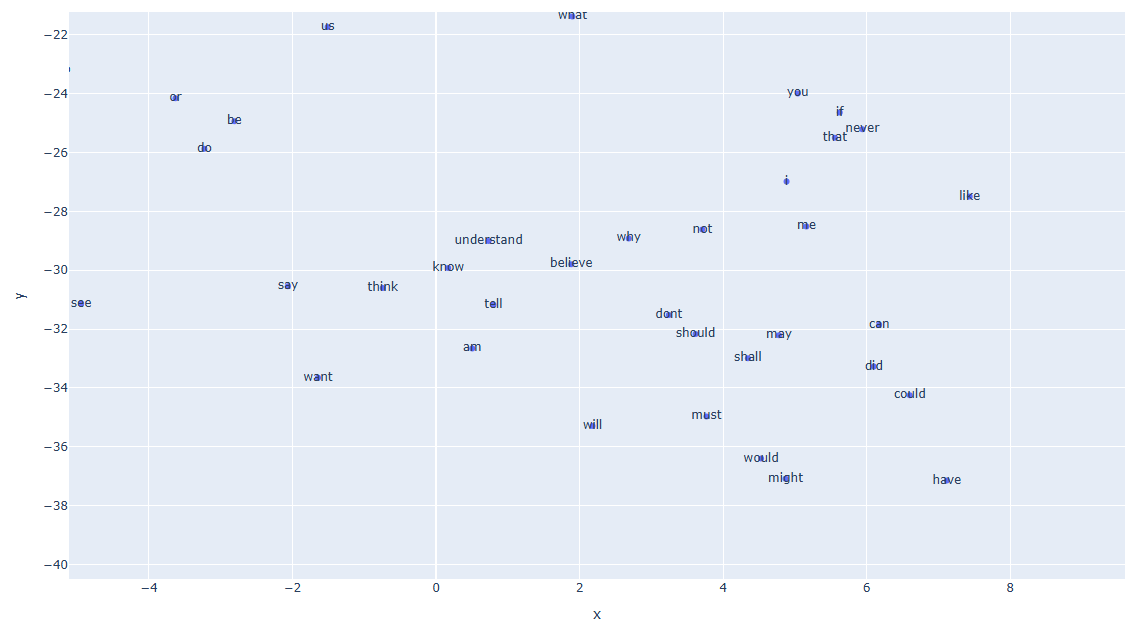

En la siguiente imagen también observamos que el modelo agrupó algunas partes del cuerpo como "hand", "face", "head" y "eyes":

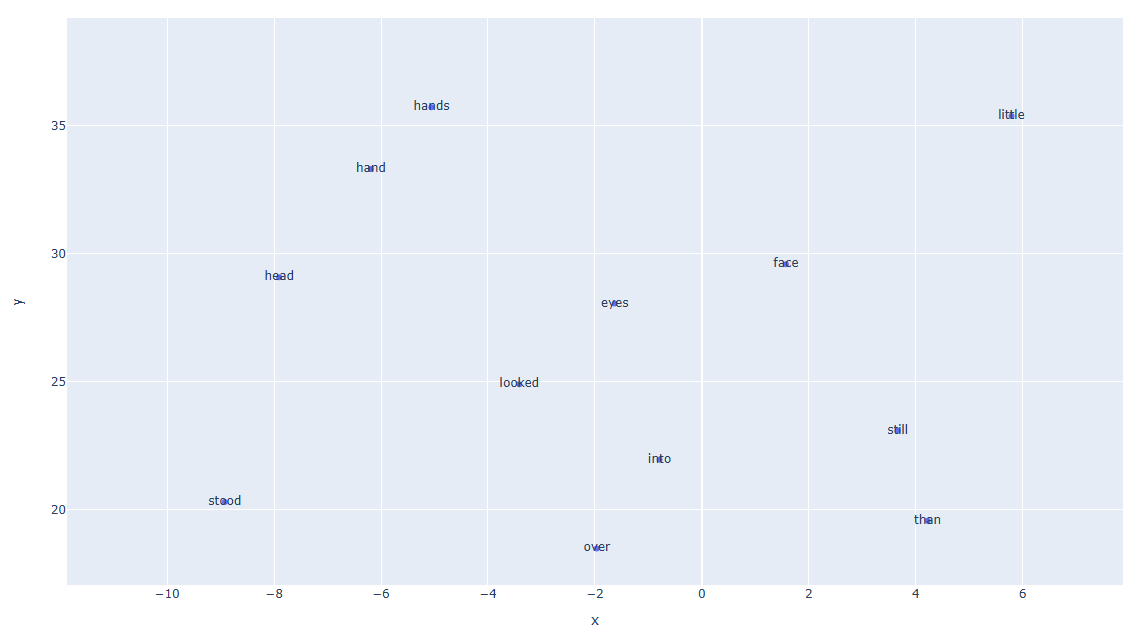

Por lo que podemos concluir que a pesar de ser un modelo bastante sencillo y haber utilizado un corpus pequeño, el modelo logra capturar algunas relaciones semánticas entre palabras comunes, como también algunos sesgos del autor.